# 07. Model Evaluation and Tuning

## Objective

Evaluate and tune the baseline models for 30-day hospital readmission prediction.

### Evaluation Principles

- Preserve the approved patient-level train/test split.
- Use training data only for model selection and tuning.
- Keep the test set untouched until final evaluation.
- Focus on minority-class performance rather than accuracy alone.
- Evaluate Precision, Recall, F1-score, ROC-AUC, PR-AUC, and confusion matrix.
- Perform threshold analysis because the default 0.50 threshold may not be appropriate for this imbalanced classification problem.

### Models

1. Logistic Regression
2. Random Forest
3. XGBoost
### Planned Evaluation

1. Load the approved patient-level train/test split.
2. Reuse the established preprocessing methodology.
3. Perform cross-validation on the training data.
4. Tune model parameters using training data only.
5. Analyze prediction thresholds.
6. Select candidate model configurations based on predefined evaluation criteria.
7. Evaluate the selected configuration once on the untouched test set.

In [2]:
TARGET = "readmitted_30"

print("TARGET:", TARGET)

TARGET: readmitted_30


In [1]:
# ============================================================
# 1. Imports and Configuration
# ============================================================

import os
import random

import numpy as np
import pandas as pd


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

import matplotlib.pyplot as plt


# Reproducibility
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


# Target and patient identifier
TARGET = "readmitted_30"
PATIENT_ID = "patient_nbr"

print("Imports successful.")
print("Target:", TARGET)

print("Random state:", RANDOM_STATE)

Imports successful.
Target: readmitted_30
Random state: 42


In [2]:
RANDOM_STATE = 42

In [3]:
# ============================================================
# 2. Load Dataset and Recreate Target
# ============================================================

DATA_PATH = "../data/raw/diabetic_data.csv"

df = pd.read_csv(DATA_PATH)

# Recreate the 30-day readmission target
# 1 = readmitted within 30 days
# 0 = not readmitted within 30 days
df[TARGET] = (df["readmitted"] == "<30").astype(int)

print("Dataset shape:", df.shape)
print("\nColumns:", len(df.columns))

print("\nTarget column present:", TARGET in df.columns)
print("Patient ID column present:", PATIENT_ID in df.columns)

print("\nTarget distribution:")
print(df[TARGET].value_counts())

print("\nTarget proportions:")
print(df[TARGET].value_counts(normalize=True))

Dataset shape: (101766, 51)

Columns: 51

Target column present: True
Patient ID column present: True

Target distribution:
readmitted_30
0    90409
1    11357
Name: count, dtype: int64

Target proportions:
readmitted_30
0    0.888401
1    0.111599
Name: proportion, dtype: float64


In [4]:
# ============================================================
# 3. Load Approved Patient-Level Split
# ============================================================

TRAIN_PATIENTS_PATH = "../data/processed/split/train_patients.csv"
TEST_PATIENTS_PATH = "../data/processed/split/test_patients.csv"

train_patients = pd.read_csv(TRAIN_PATIENTS_PATH)[PATIENT_ID]
test_patients = pd.read_csv(TEST_PATIENTS_PATH)[PATIENT_ID]

print("Training patients:", train_patients.nunique())
print("Test patients:", test_patients.nunique())

# Verify patient-level separation
patient_overlap = set(train_patients).intersection(set(test_patients))

print("Patients in both split files:", len(patient_overlap))

if len(patient_overlap) == 0:
    print("PASS: Approved patient-level split has no overlap.")
else:
    print("WARNING: Patient overlap detected!")

# Recreate the encounter-level train/test data
train_df = df[df[PATIENT_ID].isin(train_patients)].copy()
test_df = df[df[PATIENT_ID].isin(test_patients)].copy()

print("\nTraining encounters:", len(train_df))
print("Test encounters:", len(test_df))

print("\nTraining target distribution:")
print(train_df[TARGET].value_counts())

print("\nTest target distribution:")
print(test_df[TARGET].value_counts())

Training patients: 57214
Test patients: 14304
Patients in both split files: 0
PASS: Approved patient-level split has no overlap.

Training encounters: 81477
Test encounters: 20289

Training target distribution:
readmitted_30
0    72289
1     9188
Name: count, dtype: int64

Test target distribution:
readmitted_30
0    18120
1     2169
Name: count, dtype: int64


In [5]:
# ============================================================
# 4. Separate Features and Target
# ============================================================

ID_COLUMNS = ["encounter_id", PATIENT_ID]

# Separate target
y_train = train_df[TARGET].copy()
y_test = test_df[TARGET].copy()

# Remove target and identifiers
X_train = train_df.drop(columns=[TARGET] + ID_COLUMNS)
X_test = test_df.drop(columns=[TARGET] + ID_COLUMNS)

# Remove original readmission outcome
if "readmitted" in X_train.columns:
    X_train = X_train.drop(columns=["readmitted"])
    X_test = X_test.drop(columns=["readmitted"])

# Convert literal '?' values to actual missing values
X_train = X_train.replace("?", np.nan)
X_test = X_test.replace("?", np.nan)

# Verify no '?' values remain
print(
    "Remaining '?' values in X_train:",
    (X_train == "?").sum().sum()
)

print(
    "Remaining '?' values in X_test:",
    (X_test == "?").sum().sum()
)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTarget:", TARGET)
print("Identifier columns removed:", ID_COLUMNS)

print(
    "Original readmitted column present in X_train:",
    "readmitted" in X_train.columns
)

Remaining '?' values in X_train: 0
Remaining '?' values in X_test: 0

X_train shape: (81477, 47)
X_test shape: (20289, 47)
y_train shape: (81477,)
y_test shape: (20289,)

Target: readmitted_30
Identifier columns removed: ['encounter_id', 'patient_nbr']
Original readmitted column present in X_train: False


In [6]:
# ============================================================
# 5. Apply Finalized Feature Removal Decisions
# ============================================================

FEATURES_TO_REMOVE = [
    "examide",
    "citoglipton",
    "weight",
    "payer_code"
]

X_train = X_train.drop(
    columns=FEATURES_TO_REMOVE,
    errors="ignore"
)

X_test = X_test.drop(
    columns=FEATURES_TO_REMOVE,
    errors="ignore"
)

print("Removed features:", FEATURES_TO_REMOVE)

print("\nX_train shape after feature removal:", X_train.shape)
print("X_test shape after feature removal:", X_test.shape)

remaining_removed_features = [
    feature
    for feature in FEATURES_TO_REMOVE
    if feature in X_train.columns or feature in X_test.columns
]

print(
    "\nRemaining removed features:",
    remaining_removed_features
)

Removed features: ['examide', 'citoglipton', 'weight', 'payer_code']

X_train shape after feature removal: (81477, 43)
X_test shape after feature removal: (20289, 43)

Remaining removed features: []


In [7]:
# ============================================================
# 6. Define Feature Types
# ============================================================

NUMERICAL_FEATURES = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

CATEGORICAL_FEATURES = [
    column
    for column in X_train.columns
    if column not in NUMERICAL_FEATURES
]

HIGH_CARDINALITY_FEATURES = [
    "diag_1",
    "diag_2",
    "diag_3",
    "medical_specialty"
]

print("Numerical features:", len(NUMERICAL_FEATURES))
print("Categorical features:", len(CATEGORICAL_FEATURES))
print("Total predictors:", len(NUMERICAL_FEATURES) + len(CATEGORICAL_FEATURES))

print("\nNumerical features:")
print(NUMERICAL_FEATURES)

print("\nHigh-cardinality categorical features:")
print(HIGH_CARDINALITY_FEATURES)

# Verification
missing_numerical = [
    feature for feature in NUMERICAL_FEATURES
    if feature not in X_train.columns
]

missing_high_cardinality = [
    feature for feature in HIGH_CARDINALITY_FEATURES
    if feature not in X_train.columns
]

print("\nMissing numerical features:", missing_numerical)
print("Missing high-cardinality features:", missing_high_cardinality)

Numerical features: 8
Categorical features: 35
Total predictors: 43

Numerical features:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

High-cardinality categorical features:
['diag_1', 'diag_2', 'diag_3', 'medical_specialty']

Missing numerical features: []
Missing high-cardinality features: []


In [8]:
# ============================================================
# 7. Build Leakage-Safe Preprocessing Pipeline
# ============================================================

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="constant",
            fill_value="Unknown"
        )),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, NUMERICAL_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES)
    ]
)

print("Preprocessing pipeline created successfully.")
print("Numerical pipeline: median imputation + StandardScaler")
print("Categorical pipeline: Unknown imputation + OneHotEncoder")

Preprocessing pipeline created successfully.
Numerical pipeline: median imputation + StandardScaler
Categorical pipeline: Unknown imputation + OneHotEncoder


In [9]:
# ============================================================
# 8. Fit Preprocessing on Training Data Only
# ============================================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data transformed.")
print("Test data transformed using the training-fitted pipeline.")

print("\nProcessed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

# Verify feature counts match
print(
    "\nFeature count matches:",
    X_train_processed.shape[1] == X_test_processed.shape[1]
)

Training data transformed.
Test data transformed using the training-fitted pipeline.

Processed training shape: (81477, 2391)
Processed test shape: (20289, 2391)

Feature count matches: True


In [10]:
# ============================================================
# 8A. Diagnose Encoded Feature Count
# ============================================================

categorical_encoder = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

encoded_feature_counts = {
    feature: len(categories)
    for feature, categories in zip(
        CATEGORICAL_FEATURES,
        categorical_encoder.categories_
    )
}

encoded_features_total = sum(encoded_feature_counts.values())

print("Encoded categorical features:", encoded_features_total)
print("Numerical features:", len(NUMERICAL_FEATURES))
print("Total transformed features:", encoded_features_total + len(NUMERICAL_FEATURES))

print("\nCategorical feature category counts:")

for feature, count in encoded_feature_counts.items():
    print(f"{feature}: {count}")

Encoded categorical features: 2383
Numerical features: 8
Total transformed features: 2391

Categorical feature category counts:
race: 6
gender: 3
age: 10
admission_type_id: 8
discharge_disposition_id: 26
admission_source_id: 17
medical_specialty: 70
diag_1: 697
diag_2: 715
diag_3: 752
max_glu_serum: 4
A1Cresult: 4
metformin: 4
repaglinide: 4
nateglinide: 4
chlorpropamide: 3
glimepiride: 4
acetohexamide: 2
glipizide: 4
glyburide: 4
tolbutamide: 2
pioglitazone: 4
rosiglitazone: 4
acarbose: 4
miglitol: 4
troglitazone: 2
tolazamide: 3
insulin: 4
glyburide-metformin: 4
glipizide-metformin: 2
glimepiride-pioglitazone: 2
metformin-rosiglitazone: 2
metformin-pioglitazone: 1
change: 2
diabetesMed: 2


In [11]:
# ============================================================
# 9. Verify Processed Data
# ============================================================

print("Training shape:", X_train_processed.shape)
print("Test shape:", X_test_processed.shape)

print("\nTraining target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

print(
    "\nFeature count matches:",
    X_train_processed.shape[1] == X_test_processed.shape[1]
)

# Verify no missing values remain after preprocessing
print(
    "Training missing values:",
    np.isnan(X_train_processed.toarray()).sum()
)

print(
    "Test missing values:",
    np.isnan(X_test_processed.toarray()).sum()
)

Training shape: (81477, 2391)
Test shape: (20289, 2391)

Training target shape: (81477,)
Test target shape: (20289,)

Feature count matches: True
Training missing values: 0
Test missing values: 0


In [12]:
from pathlib import Path

model_dir = Path("../models")

print("Model directory exists:", model_dir.exists())

if model_dir.exists():
    print("\nModel files:")
    for file in model_dir.iterdir():
        print("-", file.name)

Model directory exists: True

Model files:
- random_forest_baseline.joblib
- preprocessor.joblib
- xgboost_baseline.joblib
- logistic_regression_baseline.joblib


In [13]:
# ============================================================
# 11. Load Baseline Models and Preprocessor
# ============================================================
from pathlib import Path
import joblib

MODEL_DIR = Path("../models")

logistic_model = joblib.load(
    MODEL_DIR / "logistic_regression_baseline.joblib"
)

random_forest_model = joblib.load(
    MODEL_DIR / "random_forest_baseline.joblib"
)

xgboost_model = joblib.load(
    MODEL_DIR / "xgboost_baseline.joblib"
)

preprocessor = joblib.load(
    MODEL_DIR / "preprocessor.joblib"
)

print("Models and preprocessor loaded successfully.")
print("Logistic Regression:", type(logistic_model).__name__)
print("Random Forest:", type(random_forest_model).__name__)
print("XGBoost:", type(xgboost_model).__name__)
print("Preprocessor:", type(preprocessor).__name__)

Models and preprocessor loaded successfully.
Logistic Regression: LogisticRegression
Random Forest: RandomForestClassifier
XGBoost: XGBClassifier
Preprocessor: ColumnTransformer


In [14]:
# Transform evaluation data using the training-fitted preprocessor

X_test_processed = preprocessor.transform(X_test)

print("Evaluation data transformed successfully.")
print("Processed test shape:", X_test_processed.shape)
print("Expected test rows:", len(y_test))
print(
    "Feature count:",
    X_test_processed.shape[1]
)

Evaluation data transformed successfully.
Processed test shape: (20289, 2391)
Expected test rows: 20289
Feature count: 2391


In [15]:
# ============================================================
# 13. Generate Predictions Using Saved Baseline Models
# ============================================================

# Logistic Regression
lr_test_pred = logistic_model.predict(X_test_processed)
lr_test_proba = logistic_model.predict_proba(X_test_processed)[:, 1]

# Random Forest
rf_test_pred = random_forest_model.predict(X_test_processed)
rf_test_proba = random_forest_model.predict_proba(X_test_processed)[:, 1]

# XGBoost
xgb_test_pred = xgboost_model.predict(X_test_processed)
xgb_test_proba = xgboost_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")

print("\nLogistic Regression:")
print("Predictions:", len(lr_test_pred))
print("Probabilities:", len(lr_test_proba))

print("\nRandom Forest:")
print("Predictions:", len(rf_test_pred))
print("Probabilities:", len(rf_test_proba))

print("\nXGBoost:")
print("Predictions:", len(xgb_test_pred))
print("Probabilities:", len(xgb_test_proba))

Predictions generated successfully.

Logistic Regression:
Predictions: 20289
Probabilities: 20289

Random Forest:
Predictions: 20289
Probabilities: 20289

XGBoost:
Predictions: 20289
Probabilities: 20289


In [16]:
# ============================================================
# 14. Calculate Baseline Test Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def calculate_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba)
    }

lr_metrics = calculate_metrics(
    y_test,
    lr_test_pred,
    lr_test_proba
)

rf_metrics = calculate_metrics(
    y_test,
    rf_test_pred,
    rf_test_proba
)

xgb_metrics = calculate_metrics(
    y_test,
    xgb_test_pred,
    xgb_test_proba
)

print("=== Logistic Regression ===")
for metric, value in lr_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\n=== Random Forest ===")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\n=== XGBoost ===")
for metric, value in xgb_metrics.items():
    print(f"{metric}: {value:.4f}")

=== Logistic Regression ===
Accuracy: 0.6611
Precision: 0.1710
Recall: 0.5639
F1: 0.2624
ROC-AUC: 0.6635
PR-AUC: 0.2122

=== Random Forest ===
Accuracy: 0.8927
Precision: 0.4655
Recall: 0.0249
F1: 0.0473
ROC-AUC: 0.6799
PR-AUC: 0.2177

=== XGBoost ===
Accuracy: 0.8934
Precision: 0.6875
Recall: 0.0051
F1: 0.0101
ROC-AUC: 0.6859
PR-AUC: 0.2331


=== Logistic Regression Confusion Matrix ===
[[12191  5929]
 [  946  1223]]


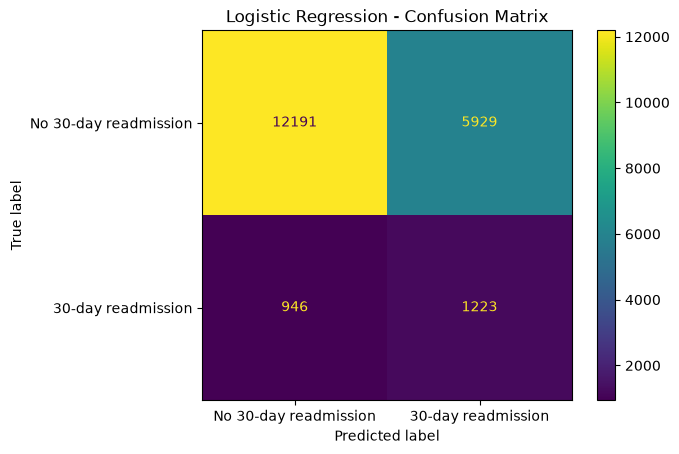


=== Random Forest Confusion Matrix ===
[[18058    62]
 [ 2115    54]]


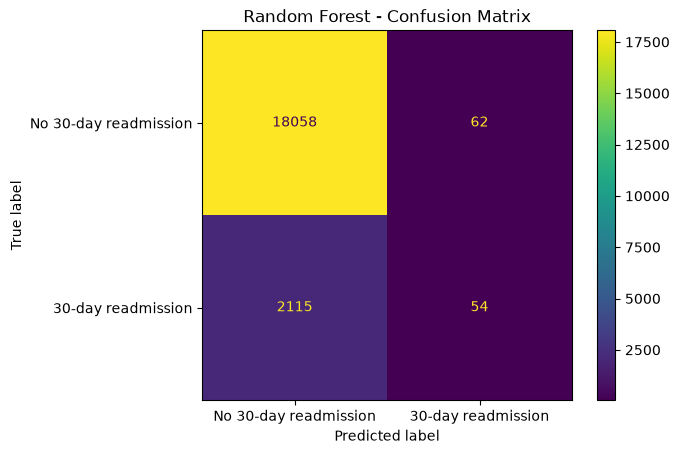


=== XGBoost Confusion Matrix ===
[[18115     5]
 [ 2158    11]]


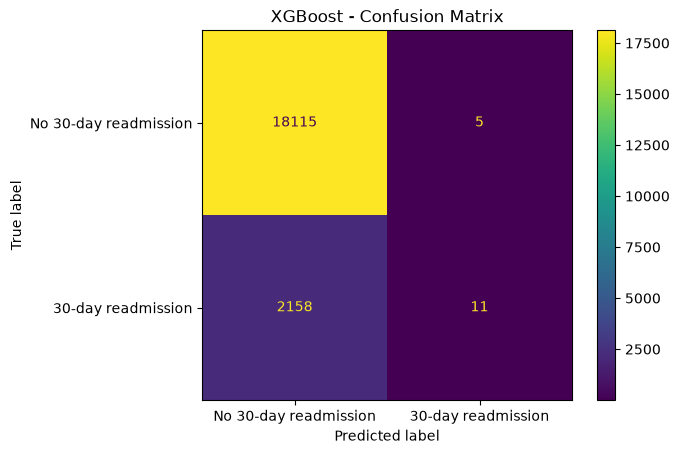

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression
lr_cm = confusion_matrix(y_test, lr_test_pred)

print("=== Logistic Regression Confusion Matrix ===")
print(lr_cm)

ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["No 30-day readmission", "30-day readmission"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# Random Forest
rf_cm = confusion_matrix(y_test, rf_test_pred)

print("\n=== Random Forest Confusion Matrix ===")
print(rf_cm)

ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["No 30-day readmission", "30-day readmission"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()


# XGBoost
xgb_cm = confusion_matrix(y_test, xgb_test_pred)

print("\n=== XGBoost Confusion Matrix ===")
print(xgb_cm)

ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["No 30-day readmission", "30-day readmission"]
).plot()

plt.title("XGBoost - Confusion Matrix")
plt.show()

In [18]:
from sklearn.metrics import classification_report

print("=== Logistic Regression Classification Report ===")

print(
    classification_report(
        y_test,
        lr_test_pred,
        target_names=[
            "No 30-day readmission",
            "30-day readmission"
        ],
        zero_division=0
    )
)


print("\n=== Random Forest Classification Report ===")

print(
    classification_report(
        y_test,
        rf_test_pred,
        target_names=[
            "No 30-day readmission",
            "30-day readmission"
        ],
        zero_division=0
    )
)


print("\n=== XGBoost Classification Report ===")

print(
    classification_report(
        y_test,
        xgb_test_pred,
        target_names=[
            "No 30-day readmission",
            "30-day readmission"
        ],
        zero_division=0
    )
)

=== Logistic Regression Classification Report ===
                       precision    recall  f1-score   support

No 30-day readmission       0.93      0.67      0.78     18120
   30-day readmission       0.17      0.56      0.26      2169

             accuracy                           0.66     20289
            macro avg       0.55      0.62      0.52     20289
         weighted avg       0.85      0.66      0.72     20289


=== Random Forest Classification Report ===
                       precision    recall  f1-score   support

No 30-day readmission       0.90      1.00      0.94     18120
   30-day readmission       0.47      0.02      0.05      2169

             accuracy                           0.89     20289
            macro avg       0.68      0.51      0.50     20289
         weighted avg       0.85      0.89      0.85     20289


=== XGBoost Classification Report ===
                       precision    recall  f1-score   support

No 30-day readmission       0.89      1.

In [19]:
results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": lr_metrics["Accuracy"],
        "Precision": lr_metrics["Precision"],
        "Recall": lr_metrics["Recall"],
        "F1": lr_metrics["F1"],
        "ROC-AUC": lr_metrics["ROC-AUC"],
        "PR-AUC": lr_metrics["PR-AUC"]
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_metrics["Accuracy"],
        "Precision": rf_metrics["Precision"],
        "Recall": rf_metrics["Recall"],
        "F1": rf_metrics["F1"],
        "ROC-AUC": rf_metrics["ROC-AUC"],
        "PR-AUC": rf_metrics["PR-AUC"]
    },
    {
        "Model": "XGBoost",
        "Accuracy": xgb_metrics["Accuracy"],
        "Precision": xgb_metrics["Precision"],
        "Recall": xgb_metrics["Recall"],
        "F1": xgb_metrics["F1"],
        "ROC-AUC": xgb_metrics["ROC-AUC"],
        "PR-AUC": xgb_metrics["PR-AUC"]
    }
]

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.661146,0.171001,0.563854,0.262418,0.663511,0.212208
1,Random Forest,0.892700,0.465517,0.024896,0.047265,0.679900,0.217685
2,XGBoost,0.893391,0.687500,0.005071,0.010069,0.685913,0.233119


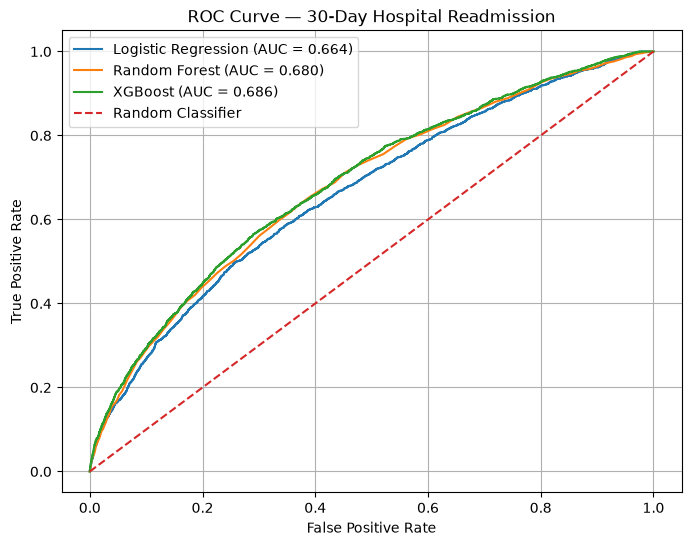

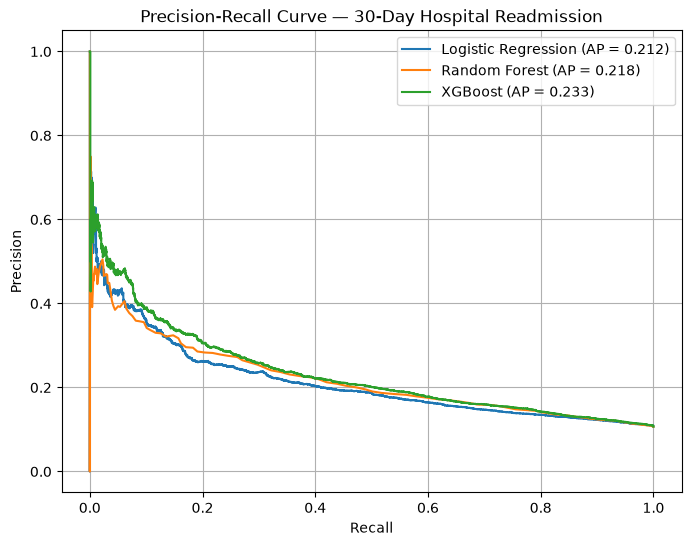

In [20]:
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

# ============================================================
# ROC Curve
# ============================================================

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_test_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_test_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {xgb_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — 30-Day Hospital Readmission")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# Precision-Recall Curve
# ============================================================

lr_precision, lr_recall, _ = precision_recall_curve(
    y_test,
    lr_test_proba
)

rf_precision, rf_recall, _ = precision_recall_curve(
    y_test,
    rf_test_proba
)

xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_test,
    xgb_test_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_recall,
    lr_precision,
    label=f"Logistic Regression (AP = {lr_metrics['PR-AUC']:.3f})"
)

plt.plot(
    rf_recall,
    rf_precision,
    label=f"Random Forest (AP = {rf_metrics['PR-AUC']:.3f})"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label=f"XGBoost (AP = {xgb_metrics['PR-AUC']:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — 30-Day Hospital Readmission")
plt.legend()
plt.grid(True)
plt.show()

## 10. Cross-Validation on Training Data

The baseline models are now evaluated on the approved test set.

The next stage is model selection and tuning using training data only.

The test set will remain untouched during cross-validation, hyperparameter tuning, and threshold selection.

In [21]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Cross-validation strategy created.")
print("Number of folds:", cv.n_splits)
print("Random state:", RANDOM_STATE)

Cross-validation strategy created.
Number of folds: 5
Random state: 42


## 11. Baseline Model Evaluation Interpretation

The baseline models were evaluated on the approved patient-level test set.

### Logistic Regression

Logistic Regression achieved:

- Accuracy: 0.6611
- Precision: 0.1710
- Recall: 0.5639
- F1-score: 0.2624
- ROC-AUC: 0.6635
- PR-AUC: 0.2122

The model identifies a substantially larger proportion of patients who experience 30-day readmission compared with Random Forest and XGBoost, as reflected by its higher positive-class recall. However, its precision is low, meaning many predicted positive cases are false positives.

### Random Forest

Random Forest achieved:

- Accuracy: 0.8927
- Precision: 0.4655
- Recall: 0.0249
- F1-score: 0.0473
- ROC-AUC: 0.6799
- PR-AUC: 0.2177

Although Random Forest has higher accuracy than Logistic Regression, its positive-class recall is very low.

### XGBoost

XGBoost achieved:

- Accuracy: 0.8934
- Precision: 0.6875
- Recall: 0.0051
- F1-score: 0.0101
- ROC-AUC: 0.6859
- PR-AUC: 0.2331

XGBoost has the highest ROC-AUC and PR-AUC among the baseline models, but its default classification threshold produces very few positive predictions and therefore very low positive-class recall.

### Class Imbalance

The target variable is imbalanced, with approximately 11% of encounters belonging to the 30-day readmission class.

Therefore, accuracy alone is not sufficient for evaluating the models.

Recall, precision, F1-score, ROC-AUC and PR-AUC should all be considered during subsequent model selection and threshold analysis.

### Current Conclusion

These results are baseline results only.

The final model and classification threshold should not be selected from these baseline results alone.

Further cross-validation, model tuning and threshold analysis will be performed using the training data. The approved test set will be reserved for final evaluation.

## 12. Model Selection and Hyperparameter Tuning

Model selection and hyperparameter tuning will be performed using the training data only.

The approved test set will remain untouched during:

- cross-validation
- hyperparameter tuning
- model selection
- threshold selection

Stratified cross-validation will be used because the target variable is imbalanced.

## 13. Cross-Validation for Model Selection

Model selection will be performed using the training data only.

The approved test set will remain untouched during cross-validation and hyperparameter tuning.

Stratified 5-fold cross-validation will be used because the target variable is imbalanced.

The primary evaluation metrics will include ROC-AUC and PR-AUC, with particular attention to PR-AUC and positive-class recall.

In [22]:
print("Available variables:")
print([name for name in globals() if not name.startswith("_")])

Available variables:
['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'os', 'random', 'np', 'pd', 'ColumnTransformer', 'SimpleImputer', 'Pipeline', 'OneHotEncoder', 'StandardScaler', 'LogisticRegression', 'RandomForestClassifier', 'StratifiedKFold', 'cross_validate', 'accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'roc_auc_score', 'average_precision_score', 'confusion_matrix', 'classification_report', 'roc_curve', 'precision_recall_curve', 'auc', 'plt', 'RANDOM_STATE', 'TARGET', 'PATIENT_ID', 'DATA_PATH', 'df', 'TRAIN_PATIENTS_PATH', 'TEST_PATIENTS_PATH', 'train_patients', 'test_patients', 'patient_overlap', 'train_df', 'test_df', 'ID_COLUMNS', 'y_train', 'y_test', 'X_train', 'X_test', 'FEATURES_TO_REMOVE', 'remaining_removed_features', 'NUMERICAL_FEATURES', 'CATEGORICAL_FEATURES', 'HIGH_CARDINALITY_FEATURES', 'missing_numerical', 'missing_high_cardinality', 'numerical_pipeline', 'categorical_pipeline', 'preprocessor', 'X_train_processed', 'X_test_processed', 'cate

In [23]:
print("DataFrame shape:", df.shape)
print("Target:", TARGET)
print("Patient ID:", PATIENT_ID)
print("Train patients path:", TRAIN_PATIENTS_PATH)
print("Test patients path:", TEST_PATIENTS_PATH)

DataFrame shape: (101766, 51)
Target: readmitted_30
Patient ID: patient_nbr
Train patients path: ../data/processed/split/train_patients.csv
Test patients path: ../data/processed/split/test_patients.csv


In [24]:
import os

print("Train patients exists:", os.path.exists(TRAIN_PATIENTS_PATH))
print("Test patients exists:", os.path.exists(TEST_PATIENTS_PATH))

print("Train path:", TRAIN_PATIENTS_PATH)
print("Test path:", TEST_PATIENTS_PATH)

Train patients exists: True
Test patients exists: True
Train path: ../data/processed/split/train_patients.csv
Test path: ../data/processed/split/test_patients.csv


In [25]:
import os

print("Current working directory:", os.getcwd())

print("Train exists:", os.path.exists("../data/processed/split/train_patients.csv"))
print("Test exists:", os.path.exists("../data/processed/split/test_patients.csv"))

Current working directory: /Users/pankajgupta/Desktop/ai-hospital-intelligence/notebooks
Train exists: True
Test exists: True


In [26]:
train_patients = pd.read_csv(TRAIN_PATIENTS_PATH)
test_patients = pd.read_csv(TEST_PATIENTS_PATH)

print("Train patients:", train_patients.shape)
print("Test patients:", test_patients.shape)

print("\nTrain columns:")
print(train_patients.columns.tolist())

print("\nTest columns:")
print(test_patients.columns.tolist())

Train patients: (57214, 1)
Test patients: (14304, 1)

Train columns:
['patient_nbr']

Test columns:
['patient_nbr']


In [27]:
# Create patient ID sets
train_patient_ids = set(train_patients[PATIENT_ID])
test_patient_ids = set(test_patients[PATIENT_ID])

# Split the full dataframe using patient IDs
df_train = df[df[PATIENT_ID].isin(train_patient_ids)].copy()
df_test = df[df[PATIENT_ID].isin(test_patient_ids)].copy()

print("Training data shape:", df_train.shape)
print("Test data shape:", df_test.shape)

print("\nUnique train patients:", df_train[PATIENT_ID].nunique())
print("Unique test patients:", df_test[PATIENT_ID].nunique())

Training data shape: (81477, 51)
Test data shape: (20289, 51)

Unique train patients: 57214
Unique test patients: 14304


In [28]:
train_ids = set(df_train[PATIENT_ID])
test_ids = set(df_test[PATIENT_ID])

overlap = train_ids.intersection(test_ids)

print("Patients in both train and test:", len(overlap))

Patients in both train and test: 0


In [29]:
# Separate target from input features
# Remove target and leakage/identifier columns
DROP_COLUMNS = [
    TARGET,
    "readmitted",
    "encounter_id",
    "patient_nbr"
]

X_train = df_train.drop(columns=DROP_COLUMNS)
X_test = df_test.drop(columns=DROP_COLUMNS)

y_train = df_train[TARGET].copy()
y_test = df_test[TARGET].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Target in X_train:", TARGET in X_train.columns)
print("readmitted in X_train:", "readmitted" in X_train.columns)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTraining target proportion:")
print(y_train.value_counts(normalize=True))

X_train shape: (81477, 47)
X_test shape: (20289, 47)
Target in X_train: False
readmitted in X_train: False

Training target distribution:
readmitted_30
0    72289
1     9188
Name: count, dtype: int64

Training target proportion:
readmitted_30
0    0.887232
1    0.112768
Name: proportion, dtype: float64


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Identify feature types
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numeric_features))


Categorical features: 36
Numerical features: 11


/var/folders/67/m53prws178q2hzd87j36jqgh0000gn/T/ipykernel_25240/2836496184.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [31]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]
)

print("Preprocessing + Logistic Regression pipeline created.")

Preprocessing + Logistic Regression pipeline created.


In [34]:
from sklearn.model_selection import cross_validate

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

print("Scoring metrics defined:")
print(list(scoring.keys()))

Scoring metrics defined:
['roc_auc', 'average_precision', 'accuracy', 'precision', 'recall', 'f1']


In [35]:
lr_cv = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression 5-Fold CV Results")

for metric in scoring:
    scores = lr_cv[f"test_{metric}"]
    print(
        f"{metric}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Logistic Regression 5-Fold CV Results
roc_auc: 0.6336 ± 0.0038
average_precision: 0.1923 ± 0.0051
accuracy: 0.8869 ± 0.0004
precision: 0.4626 ± 0.0462
recall: 0.0194 ± 0.0040
f1: 0.0372 ± 0.0074


In [36]:
# Check for suspicious target leakage
print("Target:", TARGET)
print("Target in X_train:", TARGET in X_train.columns)

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nFeature names:")
print(X_train.columns.tolist())

Target: readmitted_30
Target in X_train: False

X_train shape: (81477, 47)
y_train shape: (81477,)

Feature names:
['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [37]:
# Check whether any feature is identical to the target
leakage_features = []

for col in X_train.columns:
    try:
        if X_train[col].equals(y_train):
            leakage_features.append(col)
    except:
        pass

print("Features identical to target:", leakage_features)

Features identical to target: []


In [38]:
print("Unique values per feature:")
print(X_train.nunique().sort_values().head(20))

Unique values per feature:
metformin-pioglitazone      1
citoglipton                 1
examide                     1
diabetesMed                 2
metformin-rosiglitazone     2
glimepiride-pioglitazone    2
glipizide-metformin         2
acetohexamide               2
tolbutamide                 2
troglitazone                2
change                      2
A1Cresult                   3
max_glu_serum               3
chlorpropamide              3
tolazamide                  3
gender                      3
rosiglitazone               4
pioglitazone                4
glyburide                   4
glipizide                   4
dtype: int64


In [39]:
for col in X_train.select_dtypes(include=["object", "category"]).columns:
    print("\n", col)
    print(X_train[col].value_counts(dropna=False).head(10))


 race
race
Caucasian          60773
AfricanAmerican    15516
?                   1797
Hispanic            1643
Other               1222
Asian                526
Name: count, dtype: int64

 gender
gender
Female             43880
Male               37594
Unknown/Invalid        3
Name: count, dtype: int64

 age
age
[70-80)     21006
[60-70)     17859
[50-60)     13847
[80-90)     13718
[40-50)      7782
[30-40)      3013
[90-100)     2219
[20-30)      1330
[10-20)       570
[0-10)        133
Name: count, dtype: int64

 weight
weight
?            78943
[75-100)      1056
[50-75)        709
[100-125)      502
[125-150)      114
[25-50)         80
[0-25)          34
[150-175)       27
[175-200)        9
>200             3
Name: count, dtype: int64

 payer_code
payer_code
?     32214
MC    26109
HM     5003
SP     4010
BC     3702
MD     2801
CP     2031
UN     1913
CM     1555
OG      821
Name: count, dtype: int64

 medical_specialty
medical_specialty
?                             40014
Int

/var/folders/67/m53prws178q2hzd87j36jqgh0000gn/T/ipykernel_25240/4241876237.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_train.select_dtypes(include=["object", "category"]).columns:


In [40]:
print("Target in X_train:", TARGET in X_train.columns)
print("readmitted in X_train:", "readmitted" in X_train.columns)
print("encounter_id in X_train:", "encounter_id" in X_train.columns)
print("patient_nbr in X_train:", "patient_nbr" in X_train.columns)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Target in X_train: False
readmitted in X_train: False
encounter_id in X_train: False
patient_nbr in X_train: False

X_train shape: (81477, 47)
X_test shape: (20289, 47)


In [41]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numeric_features))
print("Total features:", len(X_train.columns))

Categorical features: 36
Numerical features: 11
Total features: 47


/var/folders/67/m53prws178q2hzd87j36jqgh0000gn/T/ipykernel_25240/2842816230.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [42]:
print("Before cleaning:")
print("Target in X_train:", TARGET in X_train.columns)
print("readmitted in X_train:", "readmitted" in X_train.columns)
print("encounter_id in X_train:", "encounter_id" in X_train.columns)
print("patient_nbr in X_train:", "patient_nbr" in X_train.columns)

Before cleaning:
Target in X_train: False
readmitted in X_train: False
encounter_id in X_train: False
patient_nbr in X_train: False


In [43]:
FEATURES_TO_REMOVE = [
    "examide",
    "citoglipton",
    "weight",
    "payer_code"
]

X_train = X_train.drop(columns=FEATURES_TO_REMOVE)
X_test = X_test.drop(columns=FEATURES_TO_REMOVE)

print("Removed features:", FEATURES_TO_REMOVE)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Removed features: ['examide', 'citoglipton', 'weight', 'payer_code']
X_train shape: (81477, 43)
X_test shape: (20289, 43)


In [44]:
# Rebuild feature lists after final feature removal

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numeric_features))
print("Total features:", len(X_train.columns))

Categorical features: 32
Numerical features: 11
Total features: 43


/var/folders/67/m53prws178q2hzd87j36jqgh0000gn/T/ipykernel_25240/1236741823.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [45]:
print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

print("\nTotal:", len(categorical_features) + len(numeric_features))

Categorical features:
['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

Numerical features:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Total: 43


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

# Combined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Logistic Regression pipeline
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            solver="liblinear",
            random_state=RANDOM_STATE
        ))
    ]
)

print("43-feature preprocessing + Logistic Regression pipeline created.")

43-feature preprocessing + Logistic Regression pipeline created.


In [47]:
from sklearn.model_selection import cross_validate

scoring = {
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

lr_cv = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Logistic Regression — 5-Fold Cross-Validation")
for metric in scoring:
    scores = lr_cv[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression — 5-Fold Cross-Validation
roc_auc: 0.6306 ± 0.0052
average_precision: 0.1918 ± 0.0055
accuracy: 0.6433 ± 0.0028
precision: 0.1647 ± 0.0019
recall: 0.5312 ± 0.0072
f1: 0.2514 ± 0.0029


In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Faster CV configuration for Random Forest model selection
rf_cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=rf_cv_strategy,
    scoring=scoring,
    n_jobs=1
)

print("Random Forest — 3-Fold Cross-Validation")
for metric in scoring:
    scores = rf_cv[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.4f} ± {scores.std():.4f}")

Random Forest — 3-Fold Cross-Validation
roc_auc: 0.6458 ± 0.0039
average_precision: 0.1965 ± 0.0019
accuracy: 0.8856 ± 0.0004
precision: 0.4081 ± 0.0242
recall: 0.0318 ± 0.0023
f1: 0.0590 ± 0.0042


In [50]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

xgb_cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

xgb_cv = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=xgb_cv_strategy,
    scoring=scoring,
    n_jobs=1
)

print("XGBoost — 3-Fold Cross-Validation")

for metric in scoring:
    scores = xgb_cv[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.4f} ± {scores.std():.4f}")

XGBoost — 3-Fold Cross-Validation
roc_auc: 0.6716 ± 0.0018
average_precision: 0.2199 ± 0.0011
accuracy: 0.8873 ± 0.0000
precision: 0.5208 ± 0.0158
recall: 0.0077 ± 0.0010
f1: 0.0152 ± 0.0020


In [51]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

# Out-of-fold probabilities on training data only
xgb_oof_proba = cross_val_predict(
    xgb_pipeline,
    X_train,
    y_train,
    cv=xgb_cv_strategy,
    method="predict_proba",
    n_jobs=1
)[:, 1]

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (xgb_oof_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_train, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_train, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_train, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

print("XGBoost — Threshold Analysis (Training OOF Predictions)")
display(threshold_df.round(4))

XGBoost — Threshold Analysis (Training OOF Predictions)


,threshold,precision,recall,f1
0,0.10,0.1624,0.7011,0.2638
1,0.15,0.2228,0.3657,0.2769
2,0.20,0.2795,0.1935,0.2287
3,0.25,0.3424,0.1055,0.1613
4,0.30,0.3896,0.0655,0.1122
5,0.35,0.4131,0.0365,0.0670
6,0.40,0.4818,0.0231,0.0440
7,0.45,0.5273,0.0147,0.0286
8,0.50,0.5221,0.0077,0.0152


In [52]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

# 3-fold CV strategy for consistent threshold comparison
threshold_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Logistic Regression OOF probabilities
lr_oof_proba = cross_val_predict(
    lr_pipeline,
    X_train,
    y_train,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

# Random Forest OOF probabilities
rf_oof_proba = cross_val_predict(
    rf_pipeline,
    X_train,
    y_train,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

print("OOF probability generation completed.")
print("LR OOF predictions:", len(lr_oof_proba))
print("RF OOF predictions:", len(rf_oof_proba))

OOF probability generation completed.
LR OOF predictions: 81477
RF OOF predictions: 81477


In [53]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results_lr_rf = []

for model_name, oof_proba in [
    ("Logistic Regression", lr_oof_proba),
    ("Random Forest", rf_oof_proba)
]:
    for threshold in thresholds:
        y_pred_threshold = (oof_proba >= threshold).astype(int)

        threshold_results_lr_rf.append({
            "model": model_name,
            "threshold": threshold,
            "precision": precision_score(
                y_train, y_pred_threshold, zero_division=0
            ),
            "recall": recall_score(
                y_train, y_pred_threshold, zero_division=0
            ),
            "f1": f1_score(
                y_train, y_pred_threshold, zero_division=0
            )
        })

threshold_df_lr_rf = pd.DataFrame(threshold_results_lr_rf)

print("Threshold Analysis — Logistic Regression vs Random Forest")
display(threshold_df_lr_rf.round(4))

Threshold Analysis — Logistic Regression vs Random Forest


,model,threshold,precision,recall,f1
0,Logistic Regression,0.10,0.1139,0.9942,0.2043
1,Logistic Regression,0.15,0.1148,0.9841,0.2057
2,Logistic Regression,0.20,0.1163,0.9694,0.2078
3,Logistic Regression,0.25,0.1189,0.9436,0.2111
4,Logistic Regression,0.30,0.1237,0.9024,0.2175
5,Logistic Regression,0.35,0.1307,0.8387,0.2261
6,Logistic Regression,0.40,0.1399,0.7507,0.2359
7,Logistic Regression,0.45,0.1513,0.6461,0.2452
8,Logistic Regression,0.50,0.1628,0.5226,0.2483
9,Random Forest,0.10,0.1193,0.9616,0.2123


In [54]:
# Combine XGBoost threshold results with LR and RF results

xgb_threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (xgb_oof_proba >= threshold).astype(int)

    xgb_threshold_results.append({
        "model": "XGBoost",
        "threshold": threshold,
        "precision": precision_score(
            y_train, y_pred_threshold, zero_division=0
        ),
        "recall": recall_score(
            y_train, y_pred_threshold, zero_division=0
        ),
        "f1": f1_score(
            y_train, y_pred_threshold, zero_division=0
        )
    })

xgb_threshold_df = pd.DataFrame(xgb_threshold_results)

all_threshold_df = pd.concat(
    [threshold_df_lr_rf, xgb_threshold_df],
    ignore_index=True
)

print("Threshold Analysis — All Three Models")
display(all_threshold_df.round(4))

Threshold Analysis — All Three Models


,model,threshold,precision,recall,f1
0,Logistic Regression,0.10,0.1139,0.9942,0.2043
1,Logistic Regression,0.15,0.1148,0.9841,0.2057
2,Logistic Regression,0.20,0.1163,0.9694,0.2078
3,Logistic Regression,0.25,0.1189,0.9436,0.2111
4,Logistic Regression,0.30,0.1237,0.9024,0.2175
5,Logistic Regression,0.35,0.1307,0.8387,0.2261
6,Logistic Regression,0.40,0.1399,0.7507,0.2359
7,Logistic Regression,0.45,0.1513,0.6461,0.2452
8,Logistic Regression,0.50,0.1628,0.5226,0.2483
9,Random Forest,0.10,0.1193,0.9616,0.2123


In [55]:
# Candidate model configurations based on training OOF threshold analysis

candidate_configs = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "threshold": 0.50,
        "precision": 0.1628,
        "recall": 0.5226,
        "f1": 0.2483
    },
    {
        "model": "Random Forest",
        "threshold": 0.25,
        "precision": 0.1743,
        "recall": 0.5073,
        "f1": 0.2595
    },
    {
        "model": "XGBoost",
        "threshold": 0.15,
        "precision": 0.2228,
        "recall": 0.3657,
        "f1": 0.2769
    }
])

print("Candidate Model Configurations")
display(candidate_configs.round(4))

Candidate Model Configurations


,model,threshold,precision,recall,f1
0,Logistic Regression,0.50,0.1628,0.5226,0.2483
1,Random Forest,0.25,0.1743,0.5073,0.2595
2,XGBoost,0.15,0.2228,0.3657,0.2769


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Fit candidate models on the full training data
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

# Test-set probabilities
lr_test_proba = lr_pipeline.predict_proba(X_test)[:, 1]
rf_test_proba = rf_pipeline.predict_proba(X_test)[:, 1]
xgb_test_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

# Candidate thresholds
final_thresholds = {
    "Logistic Regression": 0.50,
    "Random Forest": 0.25,
    "XGBoost": 0.15
}

test_probabilities = {
    "Logistic Regression": lr_test_proba,
    "Random Forest": rf_test_proba,
    "XGBoost": xgb_test_proba
}

final_results = []

for model_name, threshold in final_thresholds.items():
    y_proba = test_probabilities[model_name]
    y_pred = (y_proba >= threshold).astype(int)

    final_results.append({
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba)
    })

final_results_df = pd.DataFrame(final_results)

print("Final Test-Set Evaluation")
display(final_results_df.round(4))

Final Test-Set Evaluation


,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.50,0.6466,0.1586,0.5357,0.2448,0.6408,0.1949
1,Random Forest,0.25,0.6787,0.1693,0.5131,0.2545,0.6494,0.1880
2,XGBoost,0.15,0.7934,0.2260,0.3845,0.2847,0.6823,0.2266


In [57]:
# Final test-set confusion matrices

final_test_predictions = {
    "Logistic Regression": (lr_test_proba >= 0.50).astype(int),
    "Random Forest": (rf_test_proba >= 0.25).astype(int),
    "XGBoost": (xgb_test_proba >= 0.15).astype(int)
}

for model_name, y_pred in final_test_predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{model_name}")
    print("Confusion Matrix:")
    print(cm)


Logistic Regression
Confusion Matrix:
[[11956  6164]
 [ 1007  1162]]

Random Forest
Confusion Matrix:
[[12657  5463]
 [ 1056  1113]]

XGBoost
Confusion Matrix:
[[15264  2856]
 [ 1335   834]]


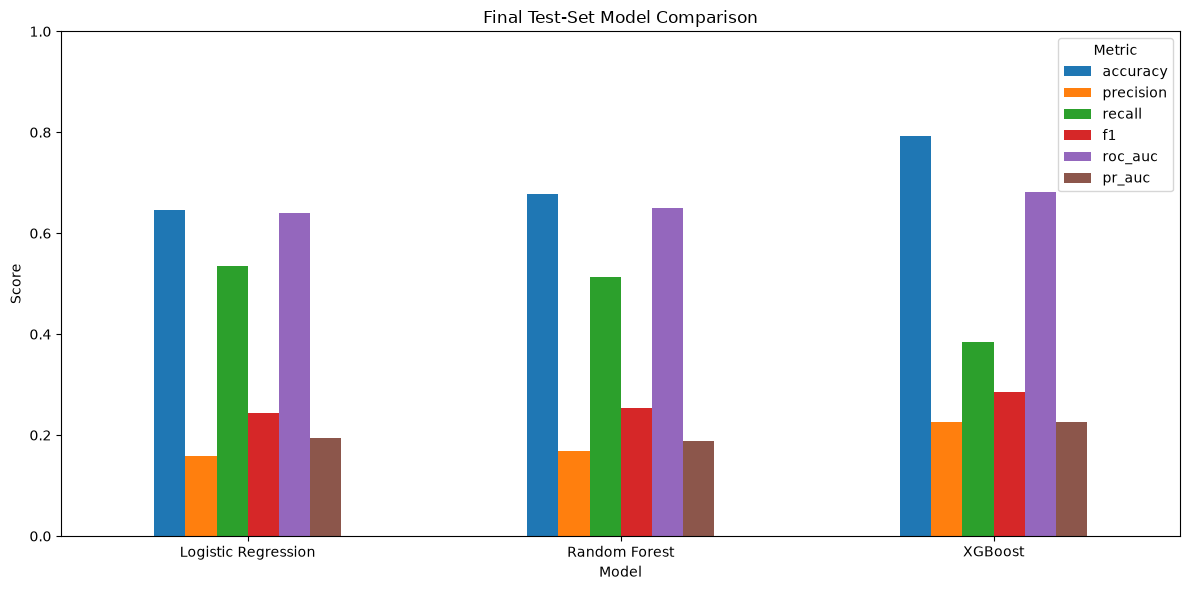

In [58]:
import matplotlib.pyplot as plt

metrics_to_plot = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc"
]

plot_df = final_results_df.set_index("model")[metrics_to_plot]

plot_df.plot(kind="bar", figsize=(12, 6))

plt.title("Final Test-Set Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [59]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

final_model_path = MODEL_DIR / "xgboost_final.joblib"
threshold_path = MODEL_DIR / "xgboost_final_threshold.joblib"

joblib.dump(xgb_pipeline, final_model_path)
joblib.dump(0.15, threshold_path)

print("Final XGBoost model saved:", final_model_path)
print("Final threshold saved:", threshold_path)

Final XGBoost model saved: ../models/xgboost_final.joblib
Final threshold saved: ../models/xgboost_final_threshold.joblib


In [60]:
from pathlib import Path
import joblib

MODEL_DIR = Path("../models")

final_model_path = MODEL_DIR / "xgboost_final.joblib"
threshold_path = MODEL_DIR / "xgboost_final_threshold.joblib"

print("Model exists:", final_model_path.exists())
print("Threshold exists:", threshold_path.exists())

loaded_model = joblib.load(final_model_path)
loaded_threshold = joblib.load(threshold_path)

print("Loaded model type:", type(loaded_model).__name__)
print("Loaded threshold:", loaded_threshold)

Model exists: True
Threshold exists: True
Loaded model type: Pipeline
Loaded threshold: 0.15


## 14. Final Model Selection

The final candidate configurations were evaluated on the approved held-out test set using thresholds selected from training-only out-of-fold predictions.

The selected XGBoost configuration uses:

- Model: XGBoost
- `n_estimators`: 200
- `max_depth`: 4
- `learning_rate`: 0.05
- `subsample`: 0.8
- `colsample_bytree`: 0.8
- Threshold: 0.15
- Random state: 42

The threshold of 0.15 was selected from the tested threshold grid using training-only out-of-fold predictions.

### Final held-out test performance

| Model | Threshold | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 0.50 | 0.6466 | 0.1586 | 0.5357 | 0.2448 | 0.6408 | 0.1949 |
| Random Forest | 0.25 | 0.6787 | 0.1693 | 0.5131 | 0.2545 | 0.6494 | 0.1880 |
| XGBoost | 0.15 | 0.7934 | 0.2260 | 0.3845 | 0.2847 | 0.6823 | 0.2266 |

The final XGBoost pipeline and its selected threshold were saved to the `models/` directory for downstream use.

**Important:** The test-set results above are reported only after model configuration and threshold selection using training data.

## 15. Evaluation Summary

The evaluation demonstrates the effect of class imbalance on model performance. Accuracy alone is not sufficient for assessing the positive readmission class.

At the selected threshold, XGBoost achieved a test-set recall of 0.3845 and F1 score of 0.2847, while Logistic Regression achieved higher recall of 0.5357. XGBoost achieved a ROC-AUC of 0.6823 and PR-AUC of 0.2266 on the held-out test set.

The final model artifact is `xgboost_final.joblib`, with a decision threshold of `0.15`.